In [183]:
# Create a model to predict the number of ppl obtaining permanent residence
# by year, region and country of origin and other factors related to
# the happiness score of the country of origin

In [184]:
import matplotlib.pyplot as plt
import pandas as pd

#immigration to the United States
df = pd.read_csv('train_y.csv') #train labels
df

,Immigration to the United States
0,5473.0
1,11481.0
2,2466.0
3,1425.0
4,3397.0
...,...
237,46542.0
238,11867.0
239,15678.0
240,51139.0


In [185]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 242 entries, 0 to 241
Data columns (total 1 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Immigration to the United States  242 non-null    float64
dtypes: float64(1)
memory usage: 2.0 KB


In [186]:
# 12 columns, has everything that contributes to overall happiness score
df1= pd.read_csv('train_x_region.csv') # train features
df1

,Year,Country,Happiness Rank,Happiness Score,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Population Estimate,Region
0,2016,France,32,6.478,6.559000,1.394880,1.005080,0.837950,0.465620,0.178080,74264176,Europe & Central Asia
1,2018,Venezuela,102,4.806,0.996000,1.469000,0.657000,0.133000,0.052000,0.056000,29174393,Latin America & Caribbean
2,2019,Costa Rica,12,7.167,1.034000,1.441000,0.963000,0.558000,0.093000,0.144000,4657652,Latin America & Caribbean
3,2019,Bolivia,61,5.779,0.776000,1.209000,0.706000,0.511000,0.064000,0.137000,10286729,Latin America & Caribbean
4,2016,Nicaragua,48,5.992,6.107000,0.693840,0.895210,0.652130,0.465820,0.162920,5994622,Latin America & Caribbean
...,...,...,...,...,...,...,...,...,...,...,...,...
237,2017,Philippines,72,5.430,5.314665,0.857699,1.253918,0.468009,0.585215,0.193513,99766788,East Asia & Pacific
238,2018,United Kingdom,11,7.190,1.244000,1.433000,0.888000,0.464000,0.082000,0.262000,73917008,Europe & Central Asia
239,2017,Ethiopia,119,4.460,4.377271,0.339234,0.864669,0.353410,0.408843,0.312651,78815294,Sub-Saharan Africa
240,2019,India,140,4.015,0.755000,0.765000,0.588000,0.498000,0.085000,0.200000,1260422331,South Asia


In [187]:
df1.Region.unique()

array(['Europe & Central Asia', 'Latin America & Caribbean',
       'Middle East & North Africa', 'East Asia & Pacific',
       'Sub-Saharan Africa', 'South Asia'], dtype=object)

In [188]:
df1.Region.value_counts()

Latin America & Caribbean     87
Europe & Central Asia         81
East Asia & Pacific           31
Middle East & North Africa    25
Sub-Saharan Africa            13
South Asia                     5
Name: Region, dtype: int64

In [189]:
df1.value_counts()

Year  Country             Happiness Rank  Happiness Score  Economy (GDP per Capita)  Family   Health (Life Expectancy)  Freedom  Trust (Government Corruption)  Generosity  Population Estimate  Region                    
2015  Argentina           30              6.574            1.05351                   1.24823  0.78723                   0.44974  0.08484                        0.11451     44841491             Latin America & Caribbean     1
2018  Poland              42              6.123            1.17600                   1.44800  0.78100                   0.54600  0.06400                        0.10800     48002042             Europe & Central Asia         1
      Denmark             3               7.555            1.35100                   1.59000  0.86800                   0.68300  0.40800                        0.28400     6628175              Europe & Central Asia         1
      Dominican Republic  83              5.302            0.98200                   1.44100  0.61400    

In [190]:
df1.describe()

,Year,Happiness Rank,Happiness Score,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Population Estimate
count,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,2.420000e+02
mean,2016.954545,58.037190,5.895496,2.884285,1.172189,0.882891,0.538545,0.258015,0.188854,8.774480e+07
std,1.435328,41.147073,1.051886,2.456517,0.307805,0.279914,0.177976,0.188388,0.117228,2.584785e+08
min,2015.000000,1.000000,3.006000,0.071200,0.107060,0.267000,0.013000,0.001000,0.000000,3.011010e+05
25%,2016.000000,23.000000,5.183750,0.982750,0.975545,0.707388,0.449185,0.083025,0.099000,7.347570e+06
50%,2017.000000,51.000000,5.946500,1.327460,1.234435,0.874320,0.546675,0.211095,0.162460,1.369083e+07
75%,2018.000000,88.750000,6.743750,5.377166,1.430750,1.021648,0.642162,0.427625,0.266100,7.318332e+07
max,2019.000000,156.000000,7.769000,7.590000,1.616463,1.558231,0.952770,0.635423,0.519120,1.567995e+09


In [191]:
# First I wanna check to see how many null objects are in the dataset
df1.isnull().sum()

Year                             0
Country                          0
Happiness Rank                   0
Happiness Score                  0
Economy (GDP per Capita)         0
Family                           0
Health (Life Expectancy)         0
Freedom                          0
Trust (Government Corruption)    0
Generosity                       0
Population Estimate              0
Region                           0
dtype: int64

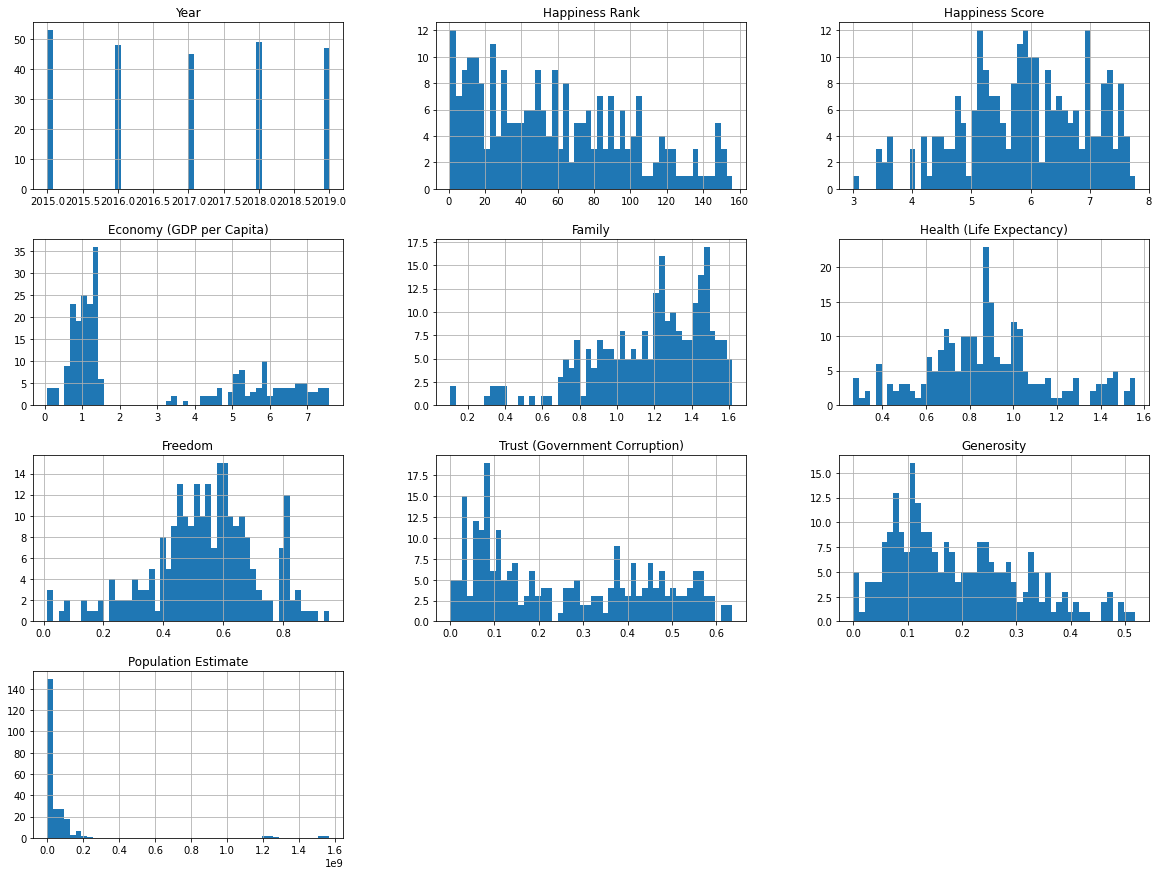

In [192]:
import matplotlib.pyplot as plt

df1.hist(bins=50, figsize=(20,15))
plt.show()

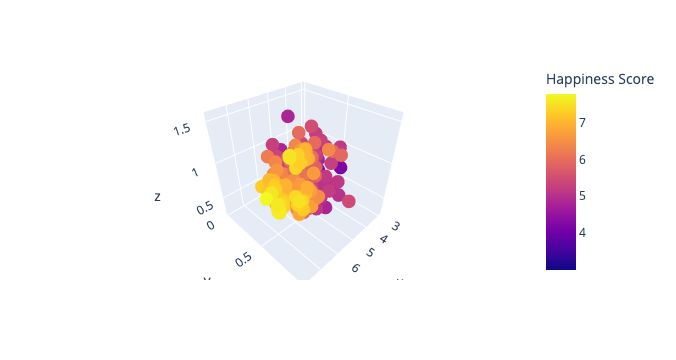

In [193]:
# Don't mind me, jsut showing off my 3D scatterpolot skills
import plotly.express as px

x = df1['Happiness Score'].values
y = df1['Freedom'].values
z = df1['Health (Life Expectancy)'].values

fig = px.scatter_3d(df1, x, y, z, color='Happiness Score', labels=x)
fig.show()

In [194]:
# Create a correlation matrix 
corr_matrix = df1.corr()
corr_matrix['Freedom'].sort_values(ascending=False, key=abs)

Freedom                          1.000000
Trust (Government Corruption)    0.616043
Economy (GDP per Capita)         0.599059
Happiness Score                  0.576130
Happiness Rank                  -0.566554
Health (Life Expectancy)         0.538678
Family                           0.433370
Year                            -0.177911
Generosity                       0.135727
Population Estimate              0.003389
Name: Freedom, dtype: float64

In [195]:
# Okay so the negative correlations is basically inverse correlation while positive is.. okay got it
# But good correlation is not technically linear correlation so...
df1.describe()

,Year,Happiness Rank,Happiness Score,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Population Estimate
count,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,2.420000e+02
mean,2016.954545,58.037190,5.895496,2.884285,1.172189,0.882891,0.538545,0.258015,0.188854,8.774480e+07
std,1.435328,41.147073,1.051886,2.456517,0.307805,0.279914,0.177976,0.188388,0.117228,2.584785e+08
min,2015.000000,1.000000,3.006000,0.071200,0.107060,0.267000,0.013000,0.001000,0.000000,3.011010e+05
25%,2016.000000,23.000000,5.183750,0.982750,0.975545,0.707388,0.449185,0.083025,0.099000,7.347570e+06
50%,2017.000000,51.000000,5.946500,1.327460,1.234435,0.874320,0.546675,0.211095,0.162460,1.369083e+07
75%,2018.000000,88.750000,6.743750,5.377166,1.430750,1.021648,0.642162,0.427625,0.266100,7.318332e+07
max,2019.000000,156.000000,7.769000,7.590000,1.616463,1.558231,0.952770,0.635423,0.519120,1.567995e+09


In [196]:
df1

,Year,Country,Happiness Rank,Happiness Score,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Population Estimate,Region
0,2016,France,32,6.478,6.559000,1.394880,1.005080,0.837950,0.465620,0.178080,74264176,Europe & Central Asia
1,2018,Venezuela,102,4.806,0.996000,1.469000,0.657000,0.133000,0.052000,0.056000,29174393,Latin America & Caribbean
2,2019,Costa Rica,12,7.167,1.034000,1.441000,0.963000,0.558000,0.093000,0.144000,4657652,Latin America & Caribbean
3,2019,Bolivia,61,5.779,0.776000,1.209000,0.706000,0.511000,0.064000,0.137000,10286729,Latin America & Caribbean
4,2016,Nicaragua,48,5.992,6.107000,0.693840,0.895210,0.652130,0.465820,0.162920,5994622,Latin America & Caribbean
...,...,...,...,...,...,...,...,...,...,...,...,...
237,2017,Philippines,72,5.430,5.314665,0.857699,1.253918,0.468009,0.585215,0.193513,99766788,East Asia & Pacific
238,2018,United Kingdom,11,7.190,1.244000,1.433000,0.888000,0.464000,0.082000,0.262000,73917008,Europe & Central Asia
239,2017,Ethiopia,119,4.460,4.377271,0.339234,0.864669,0.353410,0.408843,0.312651,78815294,Sub-Saharan Africa
240,2019,India,140,4.015,0.755000,0.765000,0.588000,0.498000,0.085000,0.200000,1260422331,South Asia


In [197]:
# Oh god what am I doing 
# Okay we can concatenate train_y and train_x then another correlation matrix
conc_df = pd.concat([df, df1], axis=1)
corr_matrix = conc_df.corr()
corr_matrix['Immigration to the United States'].sort_values(ascending=False, key=abs)

Immigration to the United States    1.000000
Population Estimate                 0.445795
Family                             -0.186854
Generosity                         -0.170803
Health (Life Expectancy)           -0.147452
Happiness Score                    -0.134443
Happiness Rank                      0.126923
Trust (Government Corruption)      -0.058378
Freedom                            -0.042866
Economy (GDP per Capita)           -0.030175
Year                               -0.017201
Name: Immigration to the United States, dtype: float64

In [198]:
# Okay so population estimate seems to have a strong correlation

In [199]:
#Okay how big is this again 
df1.shape

(242, 12)

In [200]:
# Okay and what are our columns we can use
df1.columns

Index(['Year', 'Country', 'Happiness Rank', 'Happiness Score',
       'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)',
       'Freedom', 'Trust (Government Corruption)', 'Generosity',
       'Population Estimate', 'Region'],
      dtype='object')

In [201]:
# Eww don't like those parenthesis, let's change that 
df1.rename(columns={'Economy (GDP per Capita)':'GDP', 'Trust (Government Corruption)':'Trust', 'Health (Life Expectancy)':'Lifetime'}, inplace=True)
df1.columns

Index(['Year', 'Country', 'Happiness Rank', 'Happiness Score', 'GDP', 'Family',
       'Lifetime', 'Freedom', 'Trust', 'Generosity', 'Population Estimate',
       'Region'],
      dtype='object')

In [202]:
# Check null values again bc I'm too lazy to scroll up
# Yup still looks good - no missing entries
df1.isnull().sum()

Year                   0
Country                0
Happiness Rank         0
Happiness Score        0
GDP                    0
Family                 0
Lifetime               0
Freedom                0
Trust                  0
Generosity             0
Population Estimate    0
Region                 0
dtype: int64

In [203]:
df1.describe()

,Year,Happiness Rank,Happiness Score,GDP,Family,Lifetime,Freedom,Trust,Generosity,Population Estimate
count,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,2.420000e+02
mean,2016.954545,58.037190,5.895496,2.884285,1.172189,0.882891,0.538545,0.258015,0.188854,8.774480e+07
std,1.435328,41.147073,1.051886,2.456517,0.307805,0.279914,0.177976,0.188388,0.117228,2.584785e+08
min,2015.000000,1.000000,3.006000,0.071200,0.107060,0.267000,0.013000,0.001000,0.000000,3.011010e+05
25%,2016.000000,23.000000,5.183750,0.982750,0.975545,0.707388,0.449185,0.083025,0.099000,7.347570e+06
50%,2017.000000,51.000000,5.946500,1.327460,1.234435,0.874320,0.546675,0.211095,0.162460,1.369083e+07
75%,2018.000000,88.750000,6.743750,5.377166,1.430750,1.021648,0.642162,0.427625,0.266100,7.318332e+07
max,2019.000000,156.000000,7.769000,7.590000,1.616463,1.558231,0.952770,0.635423,0.519120,1.567995e+09


In [204]:
df1.Country

0              France
1           Venezuela
2          Costa Rica
3             Bolivia
4           Nicaragua
            ...      
237       Philippines
238    United Kingdom
239          Ethiopia
240             India
241           Liberia
Name: Country, Length: 242, dtype: object

In [205]:
# Aight let's see the Country correlated with the Year
df1[['Country', 'Year']]

,Country,Year
0,France,2016
1,Venezuela,2018
2,Costa Rica,2019
3,Bolivia,2019
4,Nicaragua,2016
...,...,...
237,Philippines,2017
238,United Kingdom,2018
239,Ethiopia,2017
240,India,2019


In [206]:
# I want to set the index as Region so this is easier
# (I can reset with reset)
df1.set_index('Region', inplace=True)
df1.head()

,Year,Country,Happiness Rank,Happiness Score,GDP,Family,Lifetime,Freedom,Trust,Generosity,Population Estimate
Region,,,,,,,,,,,
Europe & Central Asia,2016,France,32,6.478,6.559,1.39488,1.00508,0.83795,0.46562,0.17808,74264176
Latin America & Caribbean,2018,Venezuela,102,4.806,0.996,1.46900,0.65700,0.13300,0.05200,0.05600,29174393
Latin America & Caribbean,2019,Costa Rica,12,7.167,1.034,1.44100,0.96300,0.55800,0.09300,0.14400,4657652
Latin America & Caribbean,2019,Bolivia,61,5.779,0.776,1.20900,0.70600,0.51100,0.06400,0.13700,10286729
Latin America & Caribbean,2016,Nicaragua,48,5.992,6.107,0.69384,0.89521,0.65213,0.46582,0.16292,5994622


In [207]:
print(df1.loc['Latin America & Caribbean'])
# Okay thats... a little bit helpful 

                           Year      Country  Happiness Rank  Happiness Score  \
Region                                                                          
Latin America & Caribbean  2018    Venezuela             102            4.806   
Latin America & Caribbean  2019   Costa Rica              12            7.167   
Latin America & Caribbean  2019      Bolivia              61            5.779   
Latin America & Caribbean  2016    Nicaragua              48            5.992   
Latin America & Caribbean  2018       Belize              49            5.956   
...                         ...          ...             ...              ...   
Latin America & Caribbean  2015         Peru              58            5.824   
Latin America & Caribbean  2019      Ecuador              50            6.028   
Latin America & Caribbean  2017     Honduras              91            5.181   
Latin America & Caribbean  2019     Paraguay              63            5.743   
Latin America & Caribbean  2

In [208]:
# Convert years to str because it's causing problems as a int
df1.columns = list(map(str, df1.columns))

In [209]:
# Check type of column headers
[print (type(x)) for x in df1.columns.values]

<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>


[None, None, None, None, None, None, None, None, None, None, None]

In [210]:
# I think we can try to visualize this now 
%matplotlib inline

import matplotlib as plt
import matplotlib.pyplot as plt
df1

,Year,Country,Happiness Rank,Happiness Score,GDP,Family,Lifetime,Freedom,Trust,Generosity,Population Estimate
Region,,,,,,,,,,,
Europe & Central Asia,2016,France,32,6.478,6.559000,1.394880,1.005080,0.837950,0.465620,0.178080,74264176
Latin America & Caribbean,2018,Venezuela,102,4.806,0.996000,1.469000,0.657000,0.133000,0.052000,0.056000,29174393
Latin America & Caribbean,2019,Costa Rica,12,7.167,1.034000,1.441000,0.963000,0.558000,0.093000,0.144000,4657652
Latin America & Caribbean,2019,Bolivia,61,5.779,0.776000,1.209000,0.706000,0.511000,0.064000,0.137000,10286729
Latin America & Caribbean,2016,Nicaragua,48,5.992,6.107000,0.693840,0.895210,0.652130,0.465820,0.162920,5994622
...,...,...,...,...,...,...,...,...,...,...,...
East Asia & Pacific,2017,Philippines,72,5.430,5.314665,0.857699,1.253918,0.468009,0.585215,0.193513,99766788
Europe & Central Asia,2018,United Kingdom,11,7.190,1.244000,1.433000,0.888000,0.464000,0.082000,0.262000,73917008
Sub-Saharan Africa,2017,Ethiopia,119,4.460,4.377271,0.339234,0.864669,0.353410,0.408843,0.312651,78815294


In [211]:
# Let's look at the correlation matrix again... 
corr_matrix = df1.corr()
corr_matrix['Happiness Score'].sort_values(ascending=False, key=abs)

Happiness Score        1.000000
Happiness Rank        -0.991314
Family                 0.698523
Freedom                0.576130
Lifetime               0.513560
Trust                  0.386655
Generosity             0.222629
Population Estimate   -0.217042
GDP                    0.185357
Year                  -0.004539
Name: Happiness Score, dtype: float64

array([[<AxesSubplot:xlabel='Year', ylabel='Year'>,
        <AxesSubplot:xlabel='Happiness Rank', ylabel='Year'>,
        <AxesSubplot:xlabel='Happiness Score', ylabel='Year'>,
        <AxesSubplot:xlabel='GDP', ylabel='Year'>,
        <AxesSubplot:xlabel='Family', ylabel='Year'>,
        <AxesSubplot:xlabel='Lifetime', ylabel='Year'>,
        <AxesSubplot:xlabel='Freedom', ylabel='Year'>,
        <AxesSubplot:xlabel='Trust', ylabel='Year'>,
        <AxesSubplot:xlabel='Generosity', ylabel='Year'>,
        <AxesSubplot:xlabel='Population Estimate', ylabel='Year'>],
       [<AxesSubplot:xlabel='Year', ylabel='Happiness Rank'>,
        <AxesSubplot:xlabel='Happiness Rank', ylabel='Happiness Rank'>,
        <AxesSubplot:xlabel='Happiness Score', ylabel='Happiness Rank'>,
        <AxesSubplot:xlabel='GDP', ylabel='Happiness Rank'>,
        <AxesSubplot:xlabel='Family', ylabel='Happiness Rank'>,
        <AxesSubplot:xlabel='Lifetime', ylabel='Happiness Rank'>,
        <AxesSubplot:xlabel='F

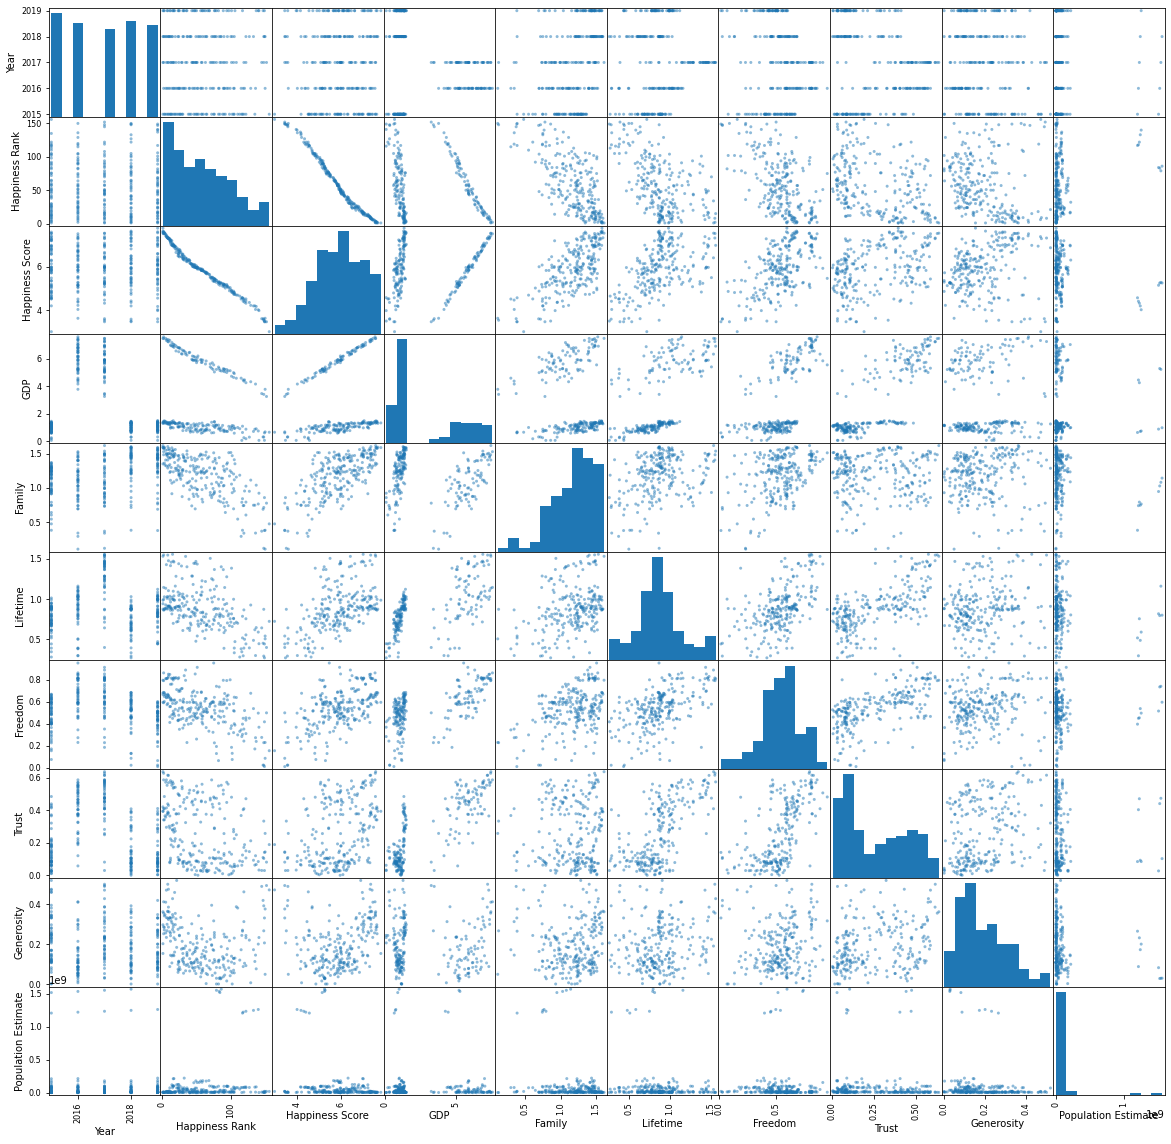

In [212]:
# And look at the linear correlation bc this doesn't really prove anything
from pandas.plotting import scatter_matrix

attributes = ['Year', 'Country', 'Happiness Rank', 'Happiness Score',
             'GDP', 'Family', 'Lifetime', 'Freedom', 'Trust', 'Generosity', 'Population Estimate']
scatter_matrix(df1[attributes], figsize=(20, 20))

## WHAT IS THIS ##

## EWW 

In [213]:
# GOd whatever let's look at the other file - gross
df2 = pd.read_csv('test_x_region.csv') #test features
df2

,Year,Country,Happiness Rank,Happiness Score,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Population Estimate,Region
0,2015,Uruguay,32,6.485,1.061660,1.208900,0.811600,0.603620,0.245580,0.232400,3997006,Latin America & Caribbean
1,2017,Brazil,22,6.635,6.544531,1.107353,1.431306,0.616552,0.437454,0.162350,216577789,Latin America & Caribbean
2,2019,Poland,40,6.182,1.206000,1.438000,0.884000,0.483000,0.050000,0.117000,48520464,Europe & Central Asia
3,2016,Spain,37,6.361,6.434000,1.342530,1.129450,0.878960,0.375450,0.061370,48608228,Europe & Central Asia
4,2017,Bulgaria,105,4.714,4.624306,1.161459,1.434379,0.708218,0.289232,0.113178,9603624,Europe & Central Asia
...,...,...,...,...,...,...,...,...,...,...,...,...
56,2019,China,93,5.191,1.029000,1.125000,0.893000,0.521000,0.100000,0.058000,1584929709,East Asia & Pacific
57,2017,Australia,10,7.284,7.211349,1.484415,1.510042,0.843887,0.601607,0.477699,23403215,East Asia & Pacific
58,2018,Iran,106,4.707,1.059000,0.771000,0.691000,0.459000,0.129000,0.282000,78574546,Middle East & North Africa
59,2016,Italy,50,5.977,6.056000,1.354950,1.041670,0.851020,0.188270,0.025560,70112681,Europe & Central Asia


In [214]:
# Choose and defend the best metric for quantifying performance of a model
df2.Region.unique()

array(['Latin America & Caribbean', 'Europe & Central Asia',
       'Sub-Saharan Africa', 'East Asia & Pacific',
       'Middle East & North Africa'], dtype=object)

In [215]:
df2.Region.value_counts()

Europe & Central Asia         29
Latin America & Caribbean     18
East Asia & Pacific            7
Middle East & North Africa     5
Sub-Saharan Africa             2
Name: Region, dtype: int64

In [216]:
df2.value_counts()

Year  Country         Happiness Rank  Happiness Score  Economy (GDP per Capita)  Family    Health (Life Expectancy)  Freedom   Trust (Government Corruption)  Generosity  Population Estimate  Region                   
2015  Australia       10              7.284            1.333580                  1.309230  0.931560                  0.651240  0.356370                       0.435620    22883136             East Asia & Pacific          1
2017  Panama          30              6.452            6.346870                  1.233748  1.373193                  0.706156  0.550027                       0.210557    3562125              Latin America & Caribbean    1
      Turkey          69              5.500            5.405135                  1.198274  1.337753                  0.637606  0.300741                       0.046693    82701710             Europe & Central Asia        1
      United Kingdom  19              6.714            6.644209                  1.441634  1.496460                  

In [217]:
df.describe()

,Immigration to the United States
count,242.000000
mean,13090.400826
std,24587.371903
min,116.000000
25%,1567.500000
50%,4167.000000
75%,12984.750000
max,172726.000000


In [218]:
# Change the columns bc the names still suck
df2.rename(columns={'Economy (GDP per Capita)':'GDP', 'Trust (Government Corruption)':'Trust', 'Health (Life Expectancy)':'Lifetime'}, inplace=True)
df2.columns

Index(['Year', 'Country', 'Happiness Rank', 'Happiness Score', 'GDP', 'Family',
       'Lifetime', 'Freedom', 'Trust', 'Generosity', 'Population Estimate',
       'Region'],
      dtype='object')

array([[<AxesSubplot:xlabel='Happiness Rank', ylabel='Happiness Rank'>,
        <AxesSubplot:xlabel='Happiness Score', ylabel='Happiness Rank'>,
        <AxesSubplot:xlabel='GDP', ylabel='Happiness Rank'>,
        <AxesSubplot:xlabel='Family', ylabel='Happiness Rank'>,
        <AxesSubplot:xlabel='Lifetime', ylabel='Happiness Rank'>,
        <AxesSubplot:xlabel='Freedom', ylabel='Happiness Rank'>,
        <AxesSubplot:xlabel='Trust', ylabel='Happiness Rank'>,
        <AxesSubplot:xlabel='Generosity', ylabel='Happiness Rank'>],
       [<AxesSubplot:xlabel='Happiness Rank', ylabel='Happiness Score'>,
        <AxesSubplot:xlabel='Happiness Score', ylabel='Happiness Score'>,
        <AxesSubplot:xlabel='GDP', ylabel='Happiness Score'>,
        <AxesSubplot:xlabel='Family', ylabel='Happiness Score'>,
        <AxesSubplot:xlabel='Lifetime', ylabel='Happiness Score'>,
        <AxesSubplot:xlabel='Freedom', ylabel='Happiness Score'>,
        <AxesSubplot:xlabel='Trust', ylabel='Happiness Score

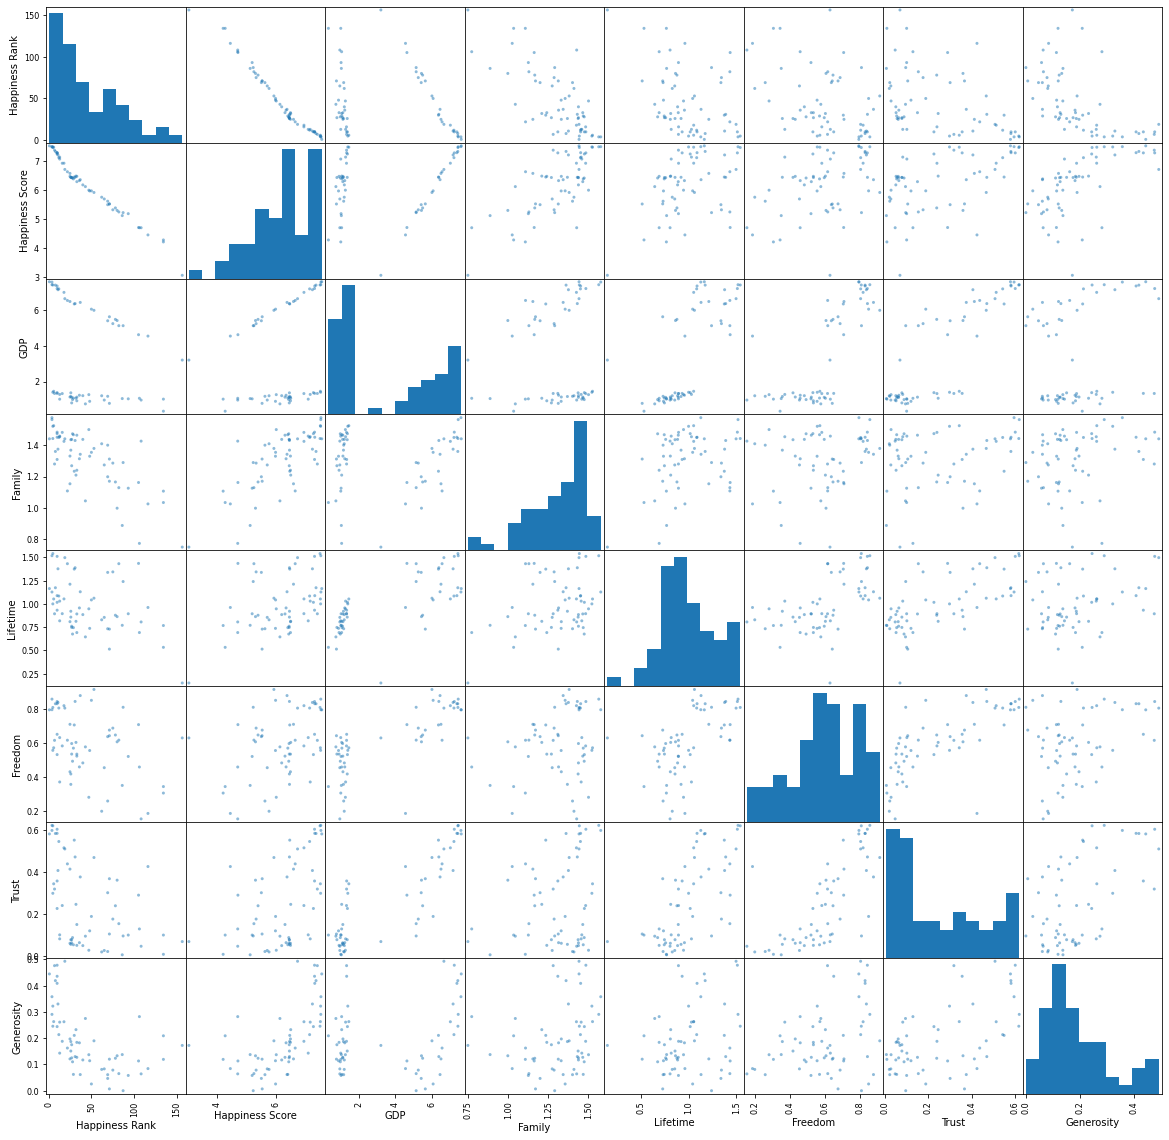

In [219]:
from pandas.plotting import scatter_matrix

attributes = ['Happiness Rank', 'Happiness Score', 'GDP', 'Family',
             'Lifetime', 'Freedom', 'Trust', 'Generosity']
scatter_matrix(df2[attributes], figsize=(20, 20))

In [220]:
# I hate my life 
# This is WORSE
# Guess we're going with the first option - at least that has some interesting correlations with the GDP

In [221]:
df1

,Year,Country,Happiness Rank,Happiness Score,GDP,Family,Lifetime,Freedom,Trust,Generosity,Population Estimate
Region,,,,,,,,,,,
Europe & Central Asia,2016,France,32,6.478,6.559000,1.394880,1.005080,0.837950,0.465620,0.178080,74264176
Latin America & Caribbean,2018,Venezuela,102,4.806,0.996000,1.469000,0.657000,0.133000,0.052000,0.056000,29174393
Latin America & Caribbean,2019,Costa Rica,12,7.167,1.034000,1.441000,0.963000,0.558000,0.093000,0.144000,4657652
Latin America & Caribbean,2019,Bolivia,61,5.779,0.776000,1.209000,0.706000,0.511000,0.064000,0.137000,10286729
Latin America & Caribbean,2016,Nicaragua,48,5.992,6.107000,0.693840,0.895210,0.652130,0.465820,0.162920,5994622
...,...,...,...,...,...,...,...,...,...,...,...
East Asia & Pacific,2017,Philippines,72,5.430,5.314665,0.857699,1.253918,0.468009,0.585215,0.193513,99766788
Europe & Central Asia,2018,United Kingdom,11,7.190,1.244000,1.433000,0.888000,0.464000,0.082000,0.262000,73917008
Sub-Saharan Africa,2017,Ethiopia,119,4.460,4.377271,0.339234,0.864669,0.353410,0.408843,0.312651,78815294


In [222]:
south_asia = df1.loc['East Asia & Pacific', 'GDP']
df1.xlabel='Year' 
south_asia.head()

Region
East Asia & Pacific    1.438000
East Asia & Pacific    5.291000
East Asia & Pacific    1.294000
East Asia & Pacific    5.554000
East Asia & Pacific    5.226721
Name: GDP, dtype: float64

<AxesSubplot:xlabel='Region'>

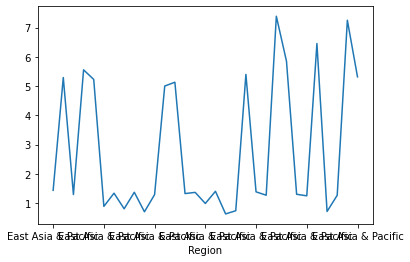

In [223]:
south_asia.plot()

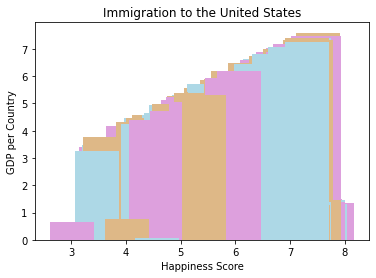

In [224]:
# I mean okay, gross x-axis labels but we can try this instead
plt.bar(df1['Happiness Score'], df1['GDP'], color=['burlywood', 'lightblue', 'plum'])
plt.xlabel('Happiness Score')
plt.ylabel('GDP per Country')
plt.title('Immigration to the United States')
plt.show()

In [225]:
# Huh okay
# So the GDP does just have this direct affect on the overall happiness of a country
# Good to know
# Now I wanna try with the Happiness RANK

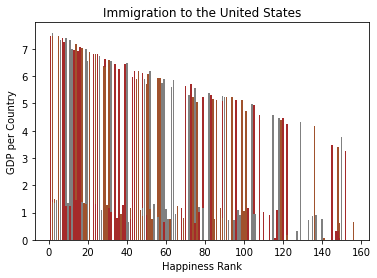

In [226]:
plt.bar(df1['Happiness Rank'], df1['GDP'], color=['grey', 'brown', 'sienna'])
plt.xlabel('Happiness Rank')
plt.ylabel('GDP per Country')
plt.title('Immigration to the United States')
plt.show()

In [227]:
# Okay that's cool 
# So the higher the GDP the lower the happiness rank interesting interesting
# I'm just screwing around with graphs at this point, I apologize
# Let's do some feature engineering
df1['Rank_Per_Country'] = df1['Happiness Rank'] / df1['Population Estimate']

In [228]:
# Create anothe correlation matrix
corr_matrix = df1.corr()
corr_matrix['Happiness Score'].sort_values(ascending=False, key=abs)

Happiness Score        1.000000
Happiness Rank        -0.991314
Family                 0.698523
Freedom                0.576130
Lifetime               0.513560
Trust                  0.386655
Generosity             0.222629
Population Estimate   -0.217042
GDP                    0.185357
Rank_Per_Country      -0.152079
Year                  -0.004539
Name: Happiness Score, dtype: float64

In [233]:
# Okay that's enough repetitiveness 
# Let's split and train
# Thank you David
import numpy as np

def split_train_test(data, test_ratio):
    shuffled_indices = np.random.permutation(len(data))
    test_set_size = int(len(data) * test_ratio)
    test_indices = shuffled_indices[:test_set_size]
    train_indices = shuffled_indices[test_set_size:]
    return data.iloc[train_indices], data.iloc[test_indices]

In [234]:
train_set, test_set = split_train_test(df1, 0.2)
print(len(train_set), 'train instances and', len(test_set), 'test instances.')

194 train instances and 48 test instances.


In [235]:
train_labels = train_set['Happiness Score']
test_labels = test_set['Happiness Score']
test_labels

Region
East Asia & Pacific           5.273
Europe & Central Asia         6.940
Middle East & North Africa    7.267
Europe & Central Asia         7.527
Europe & Central Asia         5.332
Middle East & North Africa    5.208
Europe & Central Asia         5.716
Middle East & North Africa    3.462
Latin America & Caribbean     6.130
East Asia & Pacific           5.886
Europe & Central Asia         5.358
Europe & Central Asia         6.123
Europe & Central Asia         5.791
Latin America & Caribbean     6.652
Europe & Central Asia         7.769
Latin America & Caribbean     5.743
Europe & Central Asia         7.054
East Asia & Pacific           5.458
Latin America & Caribbean     5.504
Latin America & Caribbean     3.582
Latin America & Caribbean     6.071
Latin America & Caribbean     6.167
Latin America & Caribbean     5.890
Europe & Central Asia         7.021
Latin America & Caribbean     6.125
Europe & Central Asia         5.973
Latin America & Caribbean     5.956
Latin America & Carib

In [236]:
# Okay that's cool, we have a total happiness score by region
# SO drop Country because we can't perform Linear Regression with a str
train_features = train_set.drop(columns=['Country'])
test_features = test_set.drop(columns=['Country'])
test_features

,Year,Happiness Rank,Happiness Score,GDP,Family,Lifetime,Freedom,Trust,Generosity,Population Estimate,Rank_Per_Country
Region,,,,,,,,,,,
East Asia & Pacific,2017,79,5.273,5.226721,1.081166,1.160837,0.741416,0.472788,0.028807,1550935075,5.093701e-08
Europe & Central Asia,2015,18,6.940,1.335960,1.369480,0.895330,0.617770,0.287030,0.459010,4553908,3.952649e-06
Middle East & North Africa,2016,11,7.267,7.335000,1.337660,0.995370,0.849170,0.364320,0.087280,7427991,1.480885e-06
Europe & Central Asia,2015,3,7.527,1.325480,1.360580,0.874640,0.649380,0.483570,0.341390,6410367,4.679919e-07
Europe & Central Asia,2015,76,5.332,1.060980,0.946320,0.731720,0.228150,0.157460,0.122530,80863863,9.398512e-07
Middle East & North Africa,2019,89,5.208,0.801000,0.782000,0.782000,0.418000,0.076000,0.036000,37888327,2.349008e-06
Europe & Central Asia,2015,64,5.716,1.137640,1.236170,0.669260,0.366790,0.030050,0.001990,176202491,3.632185e-07
Middle East & North Africa,2017,152,3.462,3.260331,0.777153,0.396103,0.500533,0.081539,0.493664,20028596,7.589149e-06
Latin America & Caribbean,2015,42,6.130,0.764540,1.025070,0.677370,0.403500,0.117760,0.106920,7357477,5.708479e-06


In [237]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression()
reg.fit(train_features, train_labels)

LinearRegression()

In [238]:
# Test the model (still correlating with Happiness Score)
hyp = reg.predict(test_features)
hyp

array([5.27299976, 6.94      , 7.267     , 7.527     , 5.332     ,
       5.208     , 5.716     , 3.46199989, 6.13      , 5.886     ,
       5.358     , 6.123     , 5.791     , 6.65199995, 7.769     ,
       5.743     , 7.054     , 5.458     , 5.504     , 3.582     ,
       6.0710001 , 6.167     , 5.89      , 7.021     , 6.125     ,
       5.97300005, 5.95599985, 6.67      , 5.43      , 5.945     ,
       5.915     , 5.011     , 6.95100021, 4.813     , 3.006     ,
       7.187     , 6.068     , 5.155     , 7.522     , 7.53700018,
       7.31400013, 5.103     , 3.622     , 7.52199984, 6.478     ,
       4.015     , 4.906     , 5.681     ])

In [239]:
from sklearn.metrics import mean_squared_error

mean_squared_error(test_labels, hyp)

2.845651369562879e-29

In [240]:
np.sqrt(mean_squared_error(test_labels, hyp))

5.334464705631558e-15

In [241]:
# Okay that was fun, I guess
# I kinda want to add PCA to the mix tho and use kmeans
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [242]:
# Drop Country again bc it's still a str
train_features = train_set.drop(columns=['Country'])
test_features = test_set.drop(columns=['Country'])
test_features

,Year,Happiness Rank,Happiness Score,GDP,Family,Lifetime,Freedom,Trust,Generosity,Population Estimate,Rank_Per_Country
Region,,,,,,,,,,,
East Asia & Pacific,2017,79,5.273,5.226721,1.081166,1.160837,0.741416,0.472788,0.028807,1550935075,5.093701e-08
Europe & Central Asia,2015,18,6.940,1.335960,1.369480,0.895330,0.617770,0.287030,0.459010,4553908,3.952649e-06
Middle East & North Africa,2016,11,7.267,7.335000,1.337660,0.995370,0.849170,0.364320,0.087280,7427991,1.480885e-06
Europe & Central Asia,2015,3,7.527,1.325480,1.360580,0.874640,0.649380,0.483570,0.341390,6410367,4.679919e-07
Europe & Central Asia,2015,76,5.332,1.060980,0.946320,0.731720,0.228150,0.157460,0.122530,80863863,9.398512e-07
Middle East & North Africa,2019,89,5.208,0.801000,0.782000,0.782000,0.418000,0.076000,0.036000,37888327,2.349008e-06
Europe & Central Asia,2015,64,5.716,1.137640,1.236170,0.669260,0.366790,0.030050,0.001990,176202491,3.632185e-07
Middle East & North Africa,2017,152,3.462,3.260331,0.777153,0.396103,0.500533,0.081539,0.493664,20028596,7.589149e-06
Latin America & Caribbean,2015,42,6.130,0.764540,1.025070,0.677370,0.403500,0.117760,0.106920,7357477,5.708479e-06


In [243]:
# Scale the data bc why not 
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(test_features)) # test_features includes the disinclusion of Country

In [244]:
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)
df_pca = pd.DataFrame(df_pca)
df_pca.columns = ['P1', 'P2']

In [245]:
k = KMeans(n_clusters=5, tol=0, max_iter=100)
output = k.fit(df_pca)

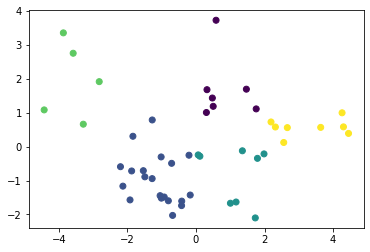

In [246]:
plt.figure()
plt.scatter(df_pca['P1'], df_pca['P2'], c=k.labels_)
plt.show()

In [247]:
df_pca['P1']

0     0.476413
1     1.352331
2     2.559014
3     1.983627
4    -1.841230
5    -2.204187
6    -1.537622
7    -2.824221
8    -1.017696
9    -0.417178
10   -2.133510
11   -0.421544
12   -0.712111
13    2.663599
14    1.729059
15    0.302722
16    1.003460
17    1.755441
18   -1.492772
19   -4.430246
20    1.468920
21   -1.011057
22   -0.807390
23    1.168212
24   -0.683223
25    2.187618
26    0.584399
27    0.063171
28   -0.205106
29   -1.047922
30   -0.169279
31   -1.925389
32    3.637375
33   -1.277520
34   -3.584057
35    0.113111
36    0.501059
37    0.319759
38    1.792377
39    4.449381
40    4.260908
41   -1.280258
42   -3.870567
43    4.301342
44    2.315065
45   -3.288863
46   -1.878033
47   -0.927382
Name: P1, dtype: float64

In [248]:
df_pca['P2']

0     1.428381
1    -0.125165
2     0.119220
3    -0.216691
4     0.302321
5    -0.593586
6    -0.710346
7     1.910382
8    -0.306145
9    -1.606716
10   -1.165844
11   -1.739177
12   -0.494077
13    0.557067
14   -2.101261
15    1.002154
16   -1.668589
17    1.108113
18   -0.891754
19    1.078549
20    1.688472
21   -1.519425
22   -1.596900
23   -1.632948
24   -2.027678
25    0.723508
26    3.717910
27   -0.245960
28   -0.255510
29   -1.445699
30   -1.427627
31   -1.571348
32    0.563968
33    0.782543
34    2.746321
35   -0.285231
36    1.183681
37    1.673854
38   -0.347437
39    0.386283
40    0.993195
41   -0.944378
42    3.346299
43    0.578887
44    0.574984
45    0.657828
46   -0.718857
47   -1.485571
Name: P2, dtype: float64

In [249]:
# Another attempt to create a 3D scatter plot and call kmeans on it
k3D = KMeans(n_clusters=5)
kmeans = k3D.fit(np.array(df_pca))

TypeError: 'KMeans' object is not subscriptable

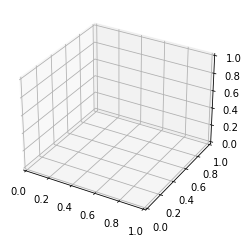

In [250]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

x = df1['Happiness Score'].values
y = df1['GDP'].values
z = df1['Freedom'].values

#ax.scatter(x, y, z, c='blue', marker='o')
#plt.scatter(df_pca['P1'], df_pca['P2'], c=k.labels_)
ax.scatter(x, y, z, c=kmeans[0])

plt.show()

In [251]:
# Well that was a flop 
# Whatever, let's try some more feature engineering
# Again, repetitive, but I'm just practicing
# So since Region and Country are Strings we can encode them then put them back together with 
# LabelBinarizer()
from sklearn.preprocessing import LabelBinarizer

# Fit the concatinated version
# For Region
region_ = LabelBinarizer()
region_.fit(conc_df['Region'])
transformed = region_.transform(conc_df['Region'])
one_region = pd.DataFrame(transformed, columns=region_.classes_)

In [252]:
# Look at the correlation natrix again for Region
corr = conc_df.corr()
corr['Immigration to the United States'].sort_values(ascending=False, key=abs).head(10)

Immigration to the United States    1.000000
Population Estimate                 0.445795
Family                             -0.186854
Generosity                         -0.170803
Health (Life Expectancy)           -0.147452
Happiness Score                    -0.134443
Happiness Rank                      0.126923
Trust (Government Corruption)      -0.058378
Freedom                            -0.042866
Economy (GDP per Capita)           -0.030175
Name: Immigration to the United States, dtype: float64

In [253]:
# Okay cool so now we can see the correlation matrix better in regards to Region
# Do the same thing for Country
country_ = LabelBinarizer()
country_.fit(conc_df['Country'])
transformed_ = country_.transform(conc_df['Country'])
one_country = pd.DataFrame(transformed_, columns=country_.classes_)

In [254]:
# Drop Coutnry
conc_df = pd.concat([conc_df, one_country], axis=1)
conc_df.drop(['Country', 'Region'], axis=1, inplace=True)

In [255]:
# Look at the correlation matrix again for Country and Region
corr = conc_df.corr()
corr['Immigration to the United States'].sort_values(ascending=False, key=abs).head(10)

Immigration to the United States    1.000000
Mexico                              0.780947
Population Estimate                 0.445795
China                               0.296674
India                               0.263632
Dominican Republic                  0.249843
Philippines                         0.188326
Family                             -0.186854
Generosity                         -0.170803
Health (Life Expectancy)           -0.147452
Name: Immigration to the United States, dtype: float64

In [256]:
# Okay that looks good, so apparently Mexico has a strong correlation as well as the Population Estimate 
# But we already knew that (not for Mexico tho that's new and interesting)
#Let's copy and paste the linear regression stuff again
# Quick look at df1 again tho
labels = conc_df['Immigration to the United States']
features = conc_df.drop(['Immigration to the United States'], axis=1)
df1

,Year,Country,Happiness Rank,Happiness Score,GDP,Family,Lifetime,Freedom,Trust,Generosity,Population Estimate,Rank_Per_Country
Region,,,,,,,,,,,,
Europe & Central Asia,2016,France,32,6.478,6.559000,1.394880,1.005080,0.837950,0.465620,0.178080,74264176,4.308942e-07
Latin America & Caribbean,2018,Venezuela,102,4.806,0.996000,1.469000,0.657000,0.133000,0.052000,0.056000,29174393,3.496217e-06
Latin America & Caribbean,2019,Costa Rica,12,7.167,1.034000,1.441000,0.963000,0.558000,0.093000,0.144000,4657652,2.576405e-06
Latin America & Caribbean,2019,Bolivia,61,5.779,0.776000,1.209000,0.706000,0.511000,0.064000,0.137000,10286729,5.929971e-06
Latin America & Caribbean,2016,Nicaragua,48,5.992,6.107000,0.693840,0.895210,0.652130,0.465820,0.162920,5994622,8.007177e-06
...,...,...,...,...,...,...,...,...,...,...,...,...
East Asia & Pacific,2017,Philippines,72,5.430,5.314665,0.857699,1.253918,0.468009,0.585215,0.193513,99766788,7.216831e-07
Europe & Central Asia,2018,United Kingdom,11,7.190,1.244000,1.433000,0.888000,0.464000,0.082000,0.262000,73917008,1.488155e-07
Sub-Saharan Africa,2017,Ethiopia,119,4.460,4.377271,0.339234,0.864669,0.353410,0.408843,0.312651,78815294,1.509859e-06


In [257]:
# Split function from sklearn
from sklearn.model_selection import train_test_split
train_features, test_features, train_labels, test_labels = train_test_split(
    features, labels, test_size=0.2)

In [258]:
# r2_score gives us the regression score
from sklearn.metrics import r2_score

reg = LinearRegression()
reg.fit(train_features, train_labels)
hypothesis = reg.predict(test_features)

print("Score: %.4f" 
      % (r2_score(test_labels, hypothesis)))

Score: 0.9731


In [259]:
# DANG .99
# Reset the name Region bc we need it as a column
df1.reset_index('Region', inplace=True)
df1.head()

,Region,Year,Country,Happiness Rank,Happiness Score,GDP,Family,Lifetime,Freedom,Trust,Generosity,Population Estimate,Rank_Per_Country
0,Europe & Central Asia,2016,France,32,6.478,6.559,1.39488,1.00508,0.83795,0.46562,0.17808,74264176,4.308942e-07
1,Latin America & Caribbean,2018,Venezuela,102,4.806,0.996,1.46900,0.65700,0.13300,0.05200,0.05600,29174393,3.496217e-06
2,Latin America & Caribbean,2019,Costa Rica,12,7.167,1.034,1.44100,0.96300,0.55800,0.09300,0.14400,4657652,2.576405e-06
3,Latin America & Caribbean,2019,Bolivia,61,5.779,0.776,1.20900,0.70600,0.51100,0.06400,0.13700,10286729,5.929971e-06
4,Latin America & Caribbean,2016,Nicaragua,48,5.992,6.107,0.69384,0.89521,0.65213,0.46582,0.16292,5994622,8.007177e-06


In [260]:
df1

,Region,Year,Country,Happiness Rank,Happiness Score,GDP,Family,Lifetime,Freedom,Trust,Generosity,Population Estimate,Rank_Per_Country
0,Europe & Central Asia,2016,France,32,6.478,6.559000,1.394880,1.005080,0.837950,0.465620,0.178080,74264176,4.308942e-07
1,Latin America & Caribbean,2018,Venezuela,102,4.806,0.996000,1.469000,0.657000,0.133000,0.052000,0.056000,29174393,3.496217e-06
2,Latin America & Caribbean,2019,Costa Rica,12,7.167,1.034000,1.441000,0.963000,0.558000,0.093000,0.144000,4657652,2.576405e-06
3,Latin America & Caribbean,2019,Bolivia,61,5.779,0.776000,1.209000,0.706000,0.511000,0.064000,0.137000,10286729,5.929971e-06
4,Latin America & Caribbean,2016,Nicaragua,48,5.992,6.107000,0.693840,0.895210,0.652130,0.465820,0.162920,5994622,8.007177e-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...
237,East Asia & Pacific,2017,Philippines,72,5.430,5.314665,0.857699,1.253918,0.468009,0.585215,0.193513,99766788,7.216831e-07
238,Europe & Central Asia,2018,United Kingdom,11,7.190,1.244000,1.433000,0.888000,0.464000,0.082000,0.262000,73917008,1.488155e-07
239,Sub-Saharan Africa,2017,Ethiopia,119,4.460,4.377271,0.339234,0.864669,0.353410,0.408843,0.312651,78815294,1.509859e-06
240,South Asia,2019,India,140,4.015,0.755000,0.765000,0.588000,0.498000,0.085000,0.200000,1260422331,1.110739e-07


In [261]:
# We have to re-drop the features now like before 
# One for Region
transformed = region_.transform(df1['Region'])
one_region = pd.DataFrame(transformed, columns=region_.classes_)

In [262]:
#Do the same for Country
transformed = country_.transform(df1['Country'])
one_country = pd.DataFrame(transformed, columns=country_.classes_)

In [263]:
df1 = pd.concat([df1, one_region, one_country], axis=1)
df1.drop(['Country', 'Region'], axis=1, inplace=True)

In [264]:
# Okay now let's predict with this model using our old feature engineering
# Which will create a csv file
prediction = reg.predict(df1)
prediction_df = pd.DataFrame(prediction)
prediction_df.to_csv("DataChallenge.csv", header=False, index=False)

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 72 is different from 79)

In [265]:
# Okay I literally can't find my way around this error? 
# It's supposed to create a new csv file that has all of the models predictions but 
# it's giving me this bull 
# But I think it's notable to mention that without the labels in a csv file we wouldn't
# even be able to test it so.. 